# MICE or IterativeImputer ( Imputing Final Boss )

## The Deep Intuition: The Sudoku Strategy
Imagine you are doing a Sudoku puzzle.
If you get stuck on a square, you don't just guess a random number (Random Sample) or guess the most common number on the board (Mode). You look at the other numbers in the row and column to make an educated guess.

Once you write that guessed number down in pencil, it suddenly helps you solve a different missing square on the other side of the board. And once you solve that square, you might look back at your first penciled-in guess and realize, "Ah! Now that I have more context, I need to adjust my first guess!"

This is exactly how MICE works. It treats your missing data like a Sudoku puzzle.

# Working of the algorithm
Let's say you have three columns: Age, Experience, and Salary. You are missing a few Ages and a few Salaries.

1. Step 1 (The Dummy Fill): It quickly fills all missing blanks with the Mean (Average) just so the dataset has no empty holes.

2. Step 2 (The Target): It takes the first column with missing data (let's say Age) and erases those dummy Mean values. It temporarily treats Age as the "Target Variable" (y).

3. Step 3 (The Machine Learning): It trains a full Machine Learning model (usually a Ridge Regression) using Experience and Salary as the features (X) to predict the missing Ages. It writes those new predictions down in pencil.

4. Step 4 (The Chain): It moves to the next column with missing data (Salary). It erases its dummy Mean values. Now, it trains a new Machine Learning model using Experience and the newly updated Ages to predict the missing Salaries.

5. Step 5 (The Loop): It loops back to Step 2. Because the Salaries are now more accurate, the model predicting Age will become more accurate. It repeats this cycle (Iteration) until the numbers stop changing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
# We MUST explicitly enable the IterativeImputer because it is an experimental feature!
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

To prove how powerful this is, we are going to build a dataset with a strong relationship: Salary = Age * 2000 + Experience * 3000.

If we use Median Imputation, it will completely ignore this mathematical rule. MICE will discover the rule on its own and use it to predict the missing numbers with terrifying accuracy.

In [3]:
# Create the suduko dataset
np.random.seed(42)
age = np.random.uniform(22, 60, 200)
experience = age - 22 + np.random.normal(0, 2, 200) # Experience is tied to age
experience = np.maximum(0, experience) # No negative experience
salary = (age * 2000) + (experience * 3000) + np.random.normal(0, 5000, 200)

df = pd.DataFrame({'Age': age, 'Experience': experience, 'Salary': salary})
df

,Age,Experience,Salary
0,36.232525,12.872475,115370.772368
1,58.127144,36.591651,225229.547751
2,49.815770,28.401915,184742.202744
3,44.749022,21.320320,148446.356666
4,27.928708,9.660257,84745.623071
...,...,...,...
195,35.269964,10.455036,100889.809600
196,49.586316,26.149427,179476.643025
197,56.090190,33.663296,210150.340547
198,55.709284,34.331099,214844.814941


In [4]:
# delete 40 random salaries
missing_indices = np.random.choice(df.index, 40, replace=False)
df_missing = df.copy()
df_missing.loc[missing_indices, 'Salary'] = np.nan

print("Dataset generated with 40 missing salaries")

Dataset generated with 40 missing salaries


In [6]:
# median imputation ( The naive way )
median_imputer = SimpleImputer(strategy='median')
df_median = pd.DataFrame(median_imputer.fit_transform(df_missing), columns=df.columns)

In [7]:
# Iterative imputer
# max_iter=10 means it will loop through the columns 10 times to refine its guesses
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(mice_imputer.fit_transform(df_missing), columns=df.columns)

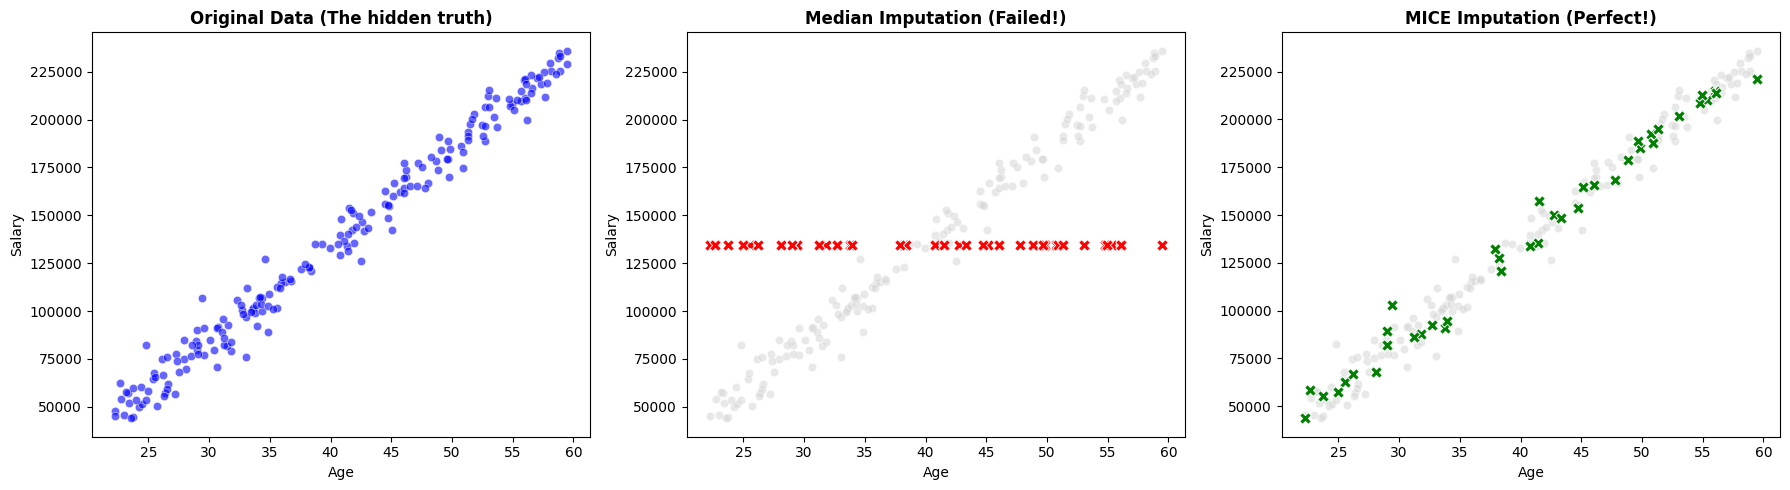

In [8]:
# Visualization

# We want to plot Salary against Age to see if the relationship was preserved
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: The Original Perfect Data
sns.scatterplot(data=df, x='Age', y='Salary', color='blue', alpha=0.6, ax=axes[0])
axes[0].set_title('Original Data (The hidden truth)', fontweight='bold')

# Plot B: Median Imputation
sns.scatterplot(data=df_median, x='Age', y='Salary', color='lightgrey', alpha=0.5, ax=axes[1])
# Highlight the imputed values in red
sns.scatterplot(data=df_median.loc[missing_indices], x='Age', y='Salary', color='red', s=70, marker='X', ax=axes[1])
axes[1].set_title('Median Imputation (Failed!)', fontweight='bold')

# Plot C: MICE Imputation
sns.scatterplot(data=df_mice, x='Age', y='Salary', color='lightgrey', alpha=0.5, ax=axes[2])
# Highlight the imputed values in green
sns.scatterplot(data=df_mice.loc[missing_indices], x='Age', y='Salary', color='green', s=70, marker='X', ax=axes[2])
axes[2].set_title('MICE Imputation (Perfect!)', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# 5. THE NUMBERS
# ==========================================
print("--- Variance of the Salary Column ---")
print(f"Original Variance: {df['Salary'].var():,.0f}")
print(f"MICE Variance:     {df_mice['Salary'].var():,.0f} (Held strong!)")
print(f"Median Variance:   {df_median['Salary'].var():,.0f} (Shrank massively!)")

--- Variance of the Salary Column ---
Original Variance: 3,199,691,313
MICE Variance:     3,217,053,078 (Held strong!)
Median Variance:   2,615,499,353 (Shrank massively!)


When the graphs generate:

1. The Middle Graph (Median): You will see a horrific, straight horizontal red line. It completely ignored the fact that older, more experienced people make more money, and just assigned everyone a flat $140k.

2. The Right Graph (MICE): The green X's fall perfectly onto the diagonal trend line of the original data. Because MICE trained a Ridge Regression model inside the imputer, it figured out the mathematical relationship between Age, Experience, and Salary, and used that formula to predict the missing values flawlessly.

MICE is computationally heavy (it trains multiple models just to clean your data), but for highly correlated datasets, it is unmatched.